In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [8]:
df = pd.read_csv(
    "C:/Users/rames/notebook/DS-1\data/processed/final_feature_dataset.csv"
)

In [9]:
print("Shape:", df.shape)

print("\nTotal Missing Values:", df.isnull().sum().sum())

Shape: (114100, 58)

Total Missing Values: 0


In [10]:
total_customers = df["customer_unique_id"].nunique()

print("Total Customers:", total_customers)

Total Customers: 96096


In [11]:
total_orders = df["order_id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 99441


In [12]:
avg_orders = total_orders / total_customers

print("Average Orders per Customer:", round(avg_orders,2))

Average Orders per Customer: 1.03


In [13]:
customer_summary = df.groupby("customer_unique_id").agg({

    "order_id":"nunique",

    "total_order_value":"sum",

    "delivery_days":"mean",

    "customer_state":"first"

}).reset_index()

In [14]:
customer_summary.columns=[

"customer_unique_id",

"total_orders",

"total_spent",

"avg_delivery_days",

"state"

]

In [15]:
average_spend = customer_summary["total_spent"].mean()

print("Average Customer Spend:", round(average_spend,2))

Average Customer Spend: 165.64


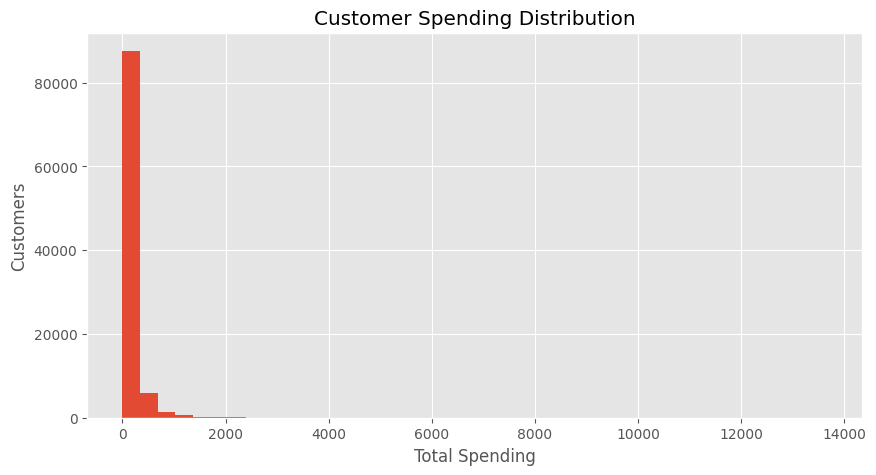

In [16]:
plt.figure(figsize=(10,5))

plt.hist(customer_summary["total_spent"], bins=40)

plt.title("Customer Spending Distribution")

plt.xlabel("Total Spending")

plt.ylabel("Customers")

plt.show()

In [17]:
frequency = customer_summary["total_orders"].value_counts().sort_index()

frequency

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

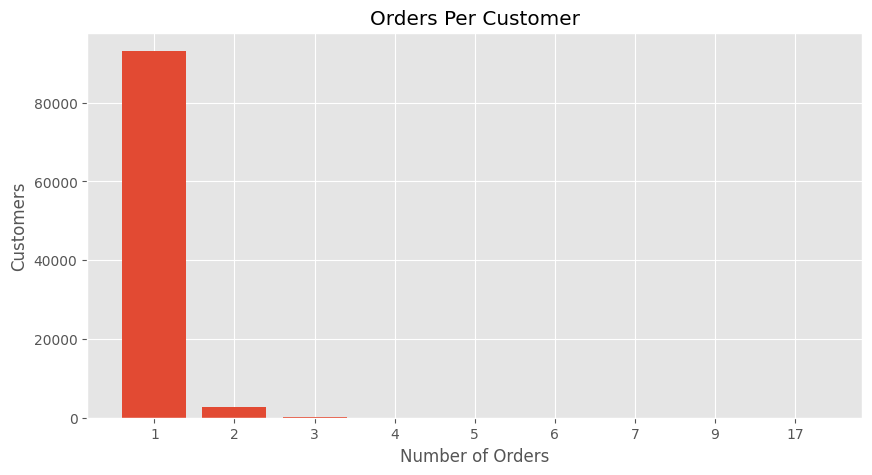

In [18]:
plt.figure(figsize=(10,5))

plt.bar(
frequency.index.astype(str),
frequency.values
)

plt.title("Orders Per Customer")

plt.xlabel("Number of Orders")

plt.ylabel("Customers")

plt.show()

In [19]:
top_customers = customer_summary.sort_values(

"total_spent",

ascending=False

).head(10)

In [20]:
top_customers

,customer_unique_id,total_orders,total_spent,avg_delivery_days,state
3826,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,18.0,RJ
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,15.0,RJ
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,11.0,ES
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,18.0,MS
26205,459bef486812aa25204be022145caa62,1,6922.21,20.0,ES
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,11.0,SP
24121,4007669dec559734d6f53e029e360987,1,6081.54,19.0,MG
35070,5d0a2980b292d049061542014e8960bf,1,4809.44,0.0,GO
89688,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,18.0,SP
27441,48e1ac109decbb87765a3eade6854098,1,4681.78,13.0,PB


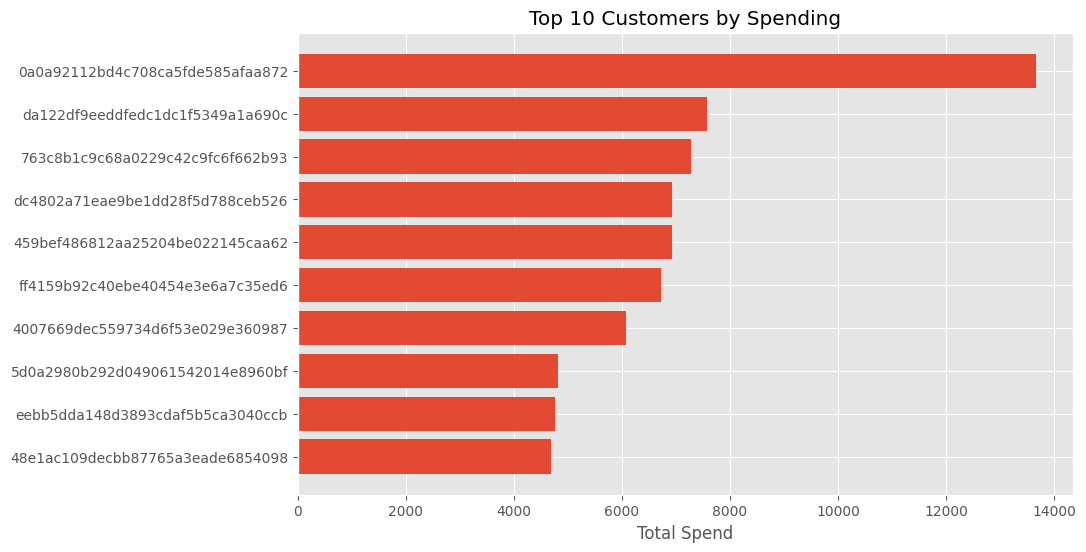

In [21]:
plt.figure(figsize=(10,6))

plt.barh(

top_customers["customer_unique_id"],

top_customers["total_spent"]

)

plt.title("Top 10 Customers by Spending")

plt.xlabel("Total Spend")

plt.gca().invert_yaxis()

plt.show()

In [22]:
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

In [23]:
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M")

In [24]:
customer_growth = df.groupby("purchase_month")["customer_unique_id"].nunique().reset_index()

In [25]:
customer_growth.columns=[

"Month",

"Unique_Customers"

]

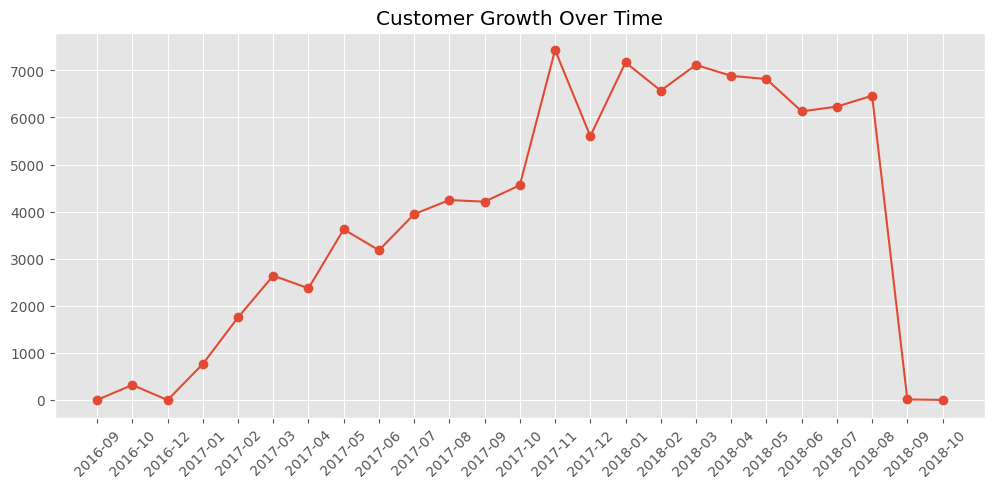

In [26]:
plt.figure(figsize=(12,5))

plt.plot(

customer_growth["Month"].astype(str),

customer_growth["Unique_Customers"],

marker="o"

)

plt.xticks(rotation=45)

plt.title("Customer Growth Over Time")

plt.show()

In [27]:
customer_summary["customer_type"] = np.where(

customer_summary["total_orders"]>1,

"Repeat",

"One-Time"

)

In [28]:
repeat_counts = customer_summary["customer_type"].value_counts()

repeat_counts

customer_type
One-Time    93099
Repeat       2997
Name: count, dtype: int64

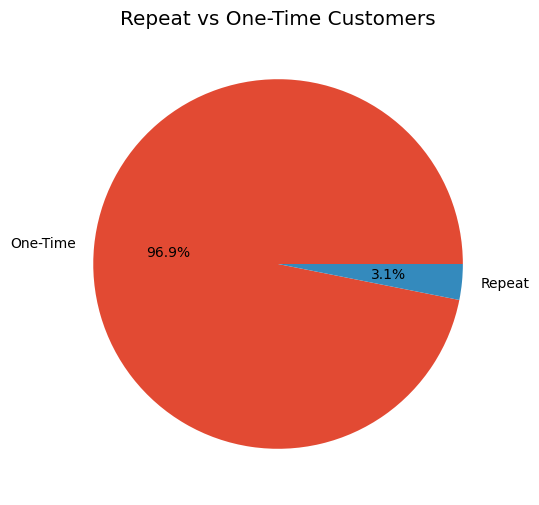

In [29]:
plt.figure(figsize=(6,6))

plt.pie(

repeat_counts,

labels=repeat_counts.index,

autopct="%1.1f%%"

)

plt.title("Repeat vs One-Time Customers")

plt.show()

In [30]:
customer_summary["CLV"] = (

customer_summary["total_spent"]

/

customer_summary["total_orders"]

)

In [31]:
customer_summary.sort_values(

"CLV",

ascending=False

).head()

,customer_unique_id,total_orders,total_spent,avg_delivery_days,state,customer_type,CLV
3826,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,18.0,RJ,One-Time,13664.08
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,11.0,ES,One-Time,7274.88
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,18.0,MS,One-Time,6929.31
26205,459bef486812aa25204be022145caa62,1,6922.21,20.0,ES,One-Time,6922.21
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,11.0,SP,One-Time,6726.66


In [32]:
state_analysis = customer_summary.groupby("state").agg({

"customer_unique_id":"count",

"total_spent":"sum"

}).sort_values(

"total_spent",

ascending=False

)

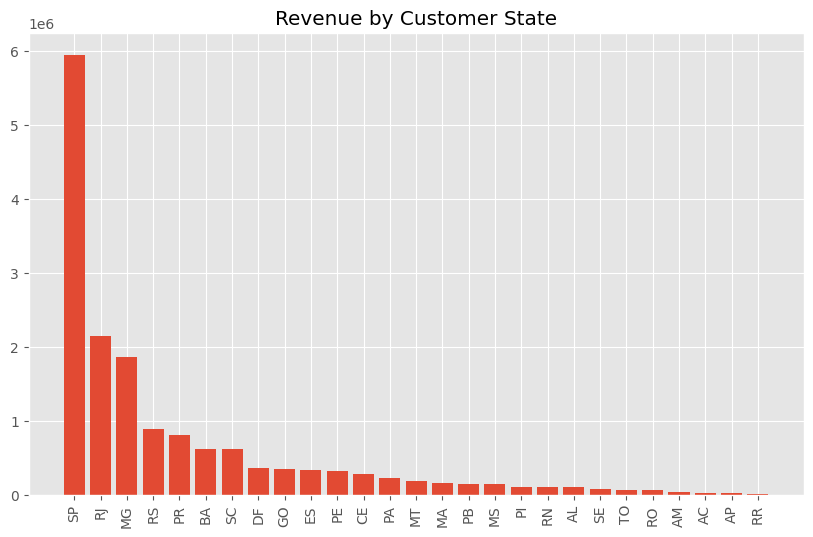

In [33]:
plt.figure(figsize=(10,6))

plt.bar(

state_analysis.index,

state_analysis["total_spent"]

)

plt.xticks(rotation=90)

plt.title("Revenue by Customer State")

plt.show()

In [34]:
customer_summary.to_csv(
    "C:/Users/rames/notebook/DS-1/reports/customer/customer_summary.csv",
    index=False
)

top_customers.to_csv(
    "C:/Users/rames/notebook/DS-1/reports/customer/top_customers.csv",
    index=False
)

customer_growth.to_csv(
    "C:/Users/rames/notebook/DS-1/reports/customer/customer_growth.csv",
    index=False
)

# Business Insights

- Identify customers who generate the highest revenue.
- Measure average customer spending.
- Understand repeat purchase behavior.
- Track customer growth over time.
- Compare customer distribution across states.
- Estimate customer lifetime value (CLV).

# Conclusion

In this notebook, customer behavior was analyzed from multiple business perspectives.

Key outcomes:

- Customer summary created
- Spending analysis completed
- Purchase frequency measured
- Top customers identified
- Customer growth analyzed
- Repeat customer analysis completed
- Basic Customer Lifetime Value (CLV) calculated

These outputs will be used in the next notebook for advanced customer segmentation using RFM analysis and K-Means clustering.